<a href="https://colab.research.google.com/github/suzannasem/STAT-4830-project-base/blob/main/notebooks/Week_5_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem Statement
This notebook aims to reconstruct an image from undersampled k-space data using a sparse representation in a Gaussian kernel basis. The primary goal is to minimize the difference between the observed undersampled k-space and the k-space of the reconstructed image, effectively recovering the image information lost due to undersampling.

tcia_utils nbia is the interface to the cancer imaging archive so theres available datasets we can use

In [ ]:

!pip install tcia_utils pydicom torch matplotlib numpy
import torch
import numpy as np
import pydicom
import matplotlib.pyplot as plt
import os
from tcia_utils import nbia

In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [ ]:
data = nbia.getSeries(collection="UPENN-GBM")
if data is None:
    raise RuntimeError("UPENN-GBM returned no data.")
print(f"'UPENN-GBM' returned {len(data)} series")

nbia.downloadSeries(data, number=1, path="./brain_mri")

# get middle slice
dcm_files = []
for root, dirs, files in os.walk("./brain_mri"):
    for f in files:
        if f.lower().endswith(".dcm"):
            dcm_files.append(os.path.join(root, f))

datasets = [pydicom.dcmread(f) for f in dcm_files]
datasets.sort(key=lambda ds: ds.InstanceNumber)

mid = len(datasets) // 2
ds = datasets[mid]
pixel_data = ds.pixel_array.astype(np.float32)

if hasattr(ds, 'RescaleSlope'):
    pixel_data = pixel_data * float(ds.RescaleSlope) + float(ds.RescaleIntercept)

print(f"Loaded slice {mid+1}/{len(datasets)}, shape: {pixel_data.shape}")


'UPENN-GBM' returned 3680 series
Loaded slice 77/152, shape: (256, 256)


## Data Requirements
*   **Input Data:** The model expects a 2D Image
*   **Preprocessing:** Data is normalized to a [0, 1] range after clipping outliers and resized to a fixed 256x256 resolution. This preprocessed 2D image serves as the target_image for reconstruction.

Trying to find an available mri collection and downloads a series, a full stack of 2d slices
sorts them by slice order and take the middle scan

Normalize and resize  so that gradient descent works faster:

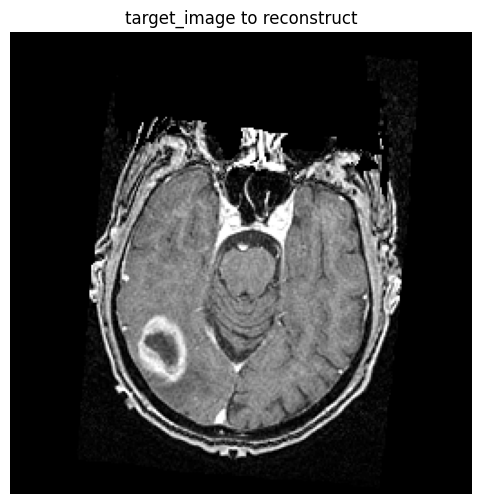

In [ ]:

# Normalize to [0, 1]
# Clip  1st and 99 percentile
p_low, p_high = np.percentile(pixel_data, (1, 99))
pixel_data = np.clip(pixel_data, p_low, p_high)
pixel_data = (pixel_data - p_low) / (p_high - p_low)

# Resize to 256x256 using torch interpolate
target_image = torch.tensor(pixel_data).unsqueeze(0).unsqueeze(0)  # -> [1, 1, H, W]
target_image = torch.nn.functional.interpolate(target_image, size=(256, 256), mode='bilinear')
target_image = target_image.squeeze()  # -> [256, 256]

plt.figure(figsize=(6, 6))
plt.imshow(target_image.numpy(), cmap='gray')
plt.title("target_image to reconstruct")
plt.axis('off')
plt.show()

In [ ]:
def create_kernel_basis(grid_size=256, num_kernels=16384, sigma=1.5):
    x = torch.linspace(0, grid_size, grid_size)
    y = torch.linspace(0, grid_size, grid_size)
    grid_x, grid_y = torch.meshgrid(x, y, indexing='ij')

    centers_x = torch.randint(0, grid_size, (num_kernels,))
    centers_y = torch.randint(0, grid_size, (num_kernels,))

    basis = []
    for i in range(num_kernels):
        dist_sq = (grid_x - centers_x[i])**2 + (grid_y - centers_y[i])**2
        # Laplacian kernel: exp(-distance / sigma)
        kernel = torch.exp(-torch.sqrt(dist_sq) / sigma)
        basis.append(kernel.flatten())

    return torch.stack(basis).T  # [65536 x num_kernels]

Phi = create_kernel_basis()
print(f"Phi shape: {Phi.shape}")

Phi shape: torch.Size([65536, 16384])


In [ ]:

target_image = target_image.to(device)
# Use fftshift to move the low frequencies to the center before masking
k_full = torch.fft.fftshift(torch.fft.fft2(target_image))

mask = torch.zeros_like(k_full, dtype=torch.complex64)
center_h, center_w = k_full.shape[-2] // 2, k_full.shape[-1] // 2
dist = 128
mask[center_h - dist : center_h + dist, center_w - dist : center_w + dist] = 1

y_obs = k_full * mask

print(f"k_full shape: {k_full.shape}")
print(f"mask shape: {mask.shape}")
print(f"y_obs shape: {y_obs.shape}")

def ifft2(k_space_data):
    """Applies 2D inverse Fast Fourier Transform and returns the real part."""
    return torch.fft.ifft2(k_space_data).real

print("ifft2 function defined.")

k_full shape: torch.Size([256, 256])
mask shape: torch.Size([256, 256])
y_obs shape: torch.Size([256, 256])
ifft2 function defined.


In [ ]:

num_kernels = Phi.shape[1]
c = (torch.randn(num_kernels, device=device) * 0.01).detach().requires_grad_(True)
learning_rate = .01
optimizer = torch.optim.Adam([c], lr=learning_rate)

print(f"Initialized coefficients 'c' with shape: {c.shape}")
print("Optimizer (Adam) initialized.")


Initialized coefficients 'c' with shape: torch.Size([16384])
Optimizer (Adam) initialized.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Move everything first
Phi = Phi.to(device).float()
target_image = target_image.to(device)
mask = mask.to(device)

# Recompute k-space on device
k_full = torch.fft.fftshift(torch.fft.fft2(target_image))
y_obs = k_full * mask

# Initialize c ON DEVICE
num_kernels = Phi.shape[1]
c = (torch.randn(num_kernels, device=device) * 0.01).requires_grad_(True)

# Create optimizer AFTER moving c
optimizer = torch.optim.Adam([c], lr=0.01)

Using device: cuda


In [ ]:

loss_history = []
num_epocs = 10000
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=2500, gamma=0.92
)
for epoch in range(num_epocs):
    optimizer.zero_grad()

    #Generate image from basis functions
    x_recon = (Phi @ c).reshape(256, 256)

   #ransform reconstruction to k-space
    k_recon = torch.fft.fftshift(torch.fft.fft2(x_recon))

   #apply the same mask to the reconstruction
    y_recon = k_recon * mask

    loss = torch.mean(torch.abs(y_recon - y_obs)**2)
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{num_epocs}, Loss: {loss.item():.4f}")
    loss.backward()
    optimizer.step()
    scheduler.step()
    loss_history.append(loss.item())

Epoch 100/10000, Loss: 541.1255
Epoch 200/10000, Loss: 441.8336
Epoch 300/10000, Loss: 402.4696
Epoch 400/10000, Loss: 381.9513
Epoch 500/10000, Loss: 369.8715
Epoch 600/10000, Loss: 362.2174
Epoch 700/10000, Loss: 357.0821
Epoch 800/10000, Loss: 353.5189
Epoch 900/10000, Loss: 350.9490
Epoch 1000/10000, Loss: 349.0621
Epoch 1100/10000, Loss: 347.6499
Epoch 1200/10000, Loss: 346.5792
Epoch 1300/10000, Loss: 345.8057
Epoch 1400/10000, Loss: 345.1204
Epoch 1500/10000, Loss: 344.6441
Epoch 1600/10000, Loss: 344.2328
Epoch 1700/10000, Loss: 343.9067
Epoch 1800/10000, Loss: 343.6720
Epoch 1900/10000, Loss: 343.4581
Epoch 2000/10000, Loss: 343.3393
Epoch 2100/10000, Loss: 343.1869
Epoch 2200/10000, Loss: 343.1633
Epoch 2300/10000, Loss: 342.9994
Epoch 2400/10000, Loss: 342.9591
Epoch 2500/10000, Loss: 342.8974
Epoch 2600/10000, Loss: 342.8403
Epoch 2700/10000, Loss: 342.8324
Epoch 2800/10000, Loss: 342.7852
Epoch 2900/10000, Loss: 342.7698
Epoch 3000/10000, Loss: 342.7715
Epoch 3100/10000, L

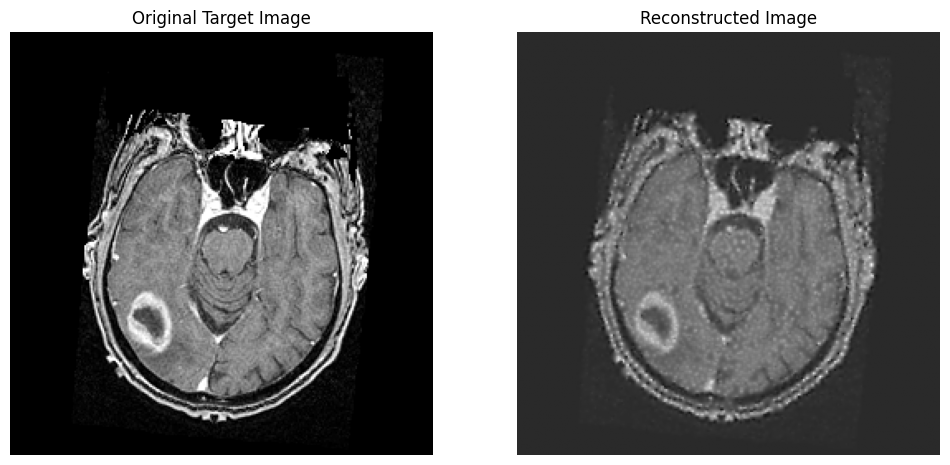

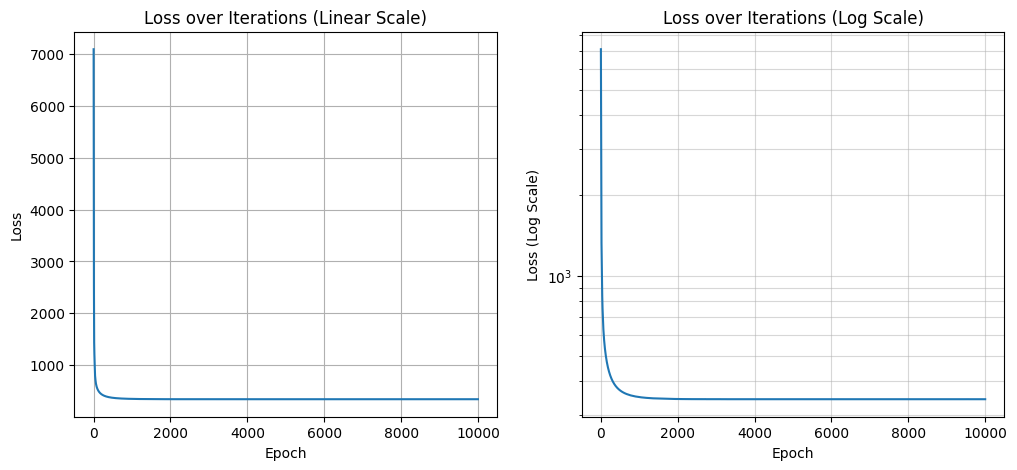

In [ ]:
import matplotlib.pyplot as plt

final_x_recon = (Phi @ c).reshape(256, 256)
reconstructed_image = final_x_recon.cpu().detach().numpy()
target_image_np = target_image.cpu().detach().numpy()

#Visual Comparison: Original vs. Reconstructed
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(target_image_np, cmap='gray')
plt.title('Original Target Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_image, cmap='gray')
plt.title('Reconstructed Image')
plt.axis('off')

plt.show()

#Optimization Performance: Linear and Log Loss Plots
plt.figure(figsize=(12, 5))

# Standard Linear Plot
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Iterations (Linear Scale)')
plt.grid(True)

# Log Scale Plot
plt.subplot(1, 2, 2)
plt.semilogy(loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss (Log Scale)')
plt.title('Loss over Iterations (Log Scale)')
plt.grid(True, which="both", ls="-", alpha=0.5)

plt.show()

## Zero-Filled FFT Baseline Reconstruction

Zero-Filled FFT MSE: 0.000000
Zero-Filled FFT PSNR: 319.81 dB


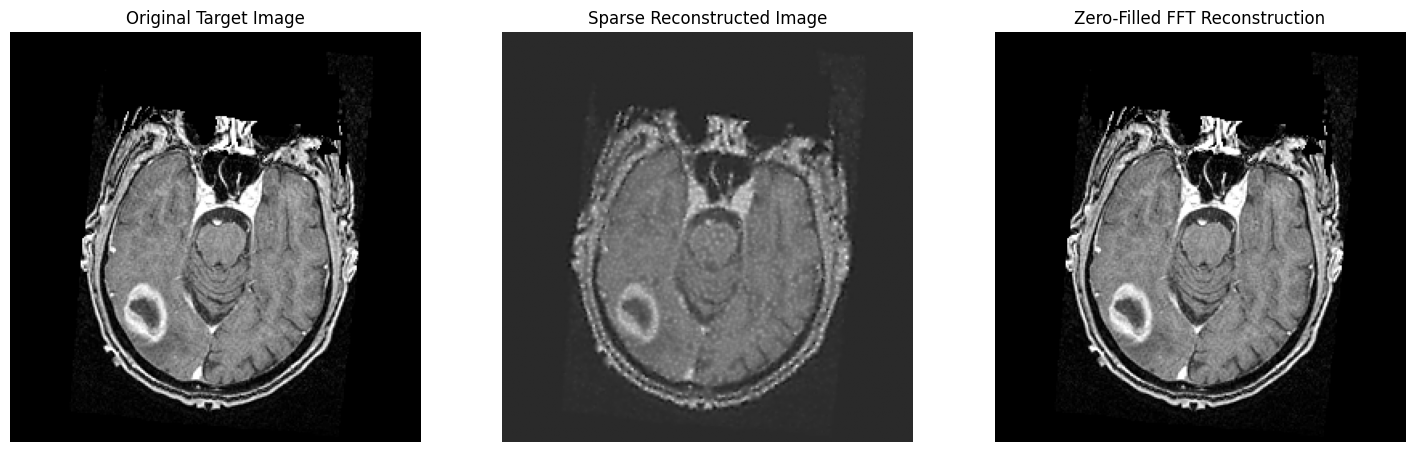


--- PSNR Comparison ---
Sparse Reconstruction PSNR: 22.82 dB
Zero-Filled FFT PSNR: 319.81 dB

--- MSE Comparison ---
Sparse Reconstruction MSE: 0.005229
Zero-Filled FFT MSE: 0.000000


In [ ]:
import torch.nn.functional as F
# Perform zero-filled IFFT reconstruction
y_zero_filled = ifft2(torch.fft.ifftshift(y_obs))
x_zf = y_zero_filled.abs()

# Calculate MSE and PSNR for the zero-filled reconstruction
mse_zero_filled = F.mse_loss(y_zero_filled.flatten(), target_image.flatten())
psnr_zero_filled = 10 * torch.log10(1.0 / mse_zero_filled)

print(f"Zero-Filled FFT MSE: {mse_zero_filled.item():.6f}")
print(f"Zero-Filled FFT PSNR: {psnr_zero_filled.item():.2f} dB")

# Visual Comparison: Original vs. Reconstructed vs. Zero-Filled
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(target_image_np, cmap='gray')
plt.title('Original Target Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(reconstructed_image, cmap='gray')
plt.title('Sparse Reconstructed Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(y_zero_filled.cpu().detach().numpy(), cmap='gray')
plt.title('Zero-Filled FFT Reconstruction')
plt.axis('off')

plt.show()

mse = F.mse_loss(final_x_recon.flatten(), target_image.flatten())
psnr = 10 * torch.log10(1.0 / mse)

print("\n--- PSNR Comparison ---")
print(f"Sparse Reconstruction PSNR: {psnr.item():.2f} dB")
print(f"Zero-Filled FFT PSNR: {psnr_zero_filled.item():.2f} dB")

print("\n--- MSE Comparison ---")
print(f"Sparse Reconstruction MSE: {mse.item():.6f}")
print(f"Zero-Filled FFT MSE: {mse_zero_filled.item():.6f}")

## Success Metrics
The performance of the image reconstruction is evaluated using:
*   **Mean Squared Error (MSE):** Measures the average squared difference between the reconstructed image and the original target image.
*   **Peak Signal-to-Noise Ratio (PSNR):** A common metric for image quality, providing a quantitative measure of reconstruction fidelity. Higher PSNR values indicate better reconstruction quality.

In [ ]:
mse = F.mse_loss(final_x_recon.flatten(), target_image.flatten())
psnr = 10 * torch.log10(1.0 / mse)
print(f"MSE: {mse.item():.6f}")
print(f"PSNR: {psnr.item():.2f} dB")

MSE: 0.005229
PSNR: 22.82 dB


## Resource Monitoring


*   System Ram - 7.8/12.7 GB
*   GPU Ram - 4.2/15.0 GB

*   Disk - 38.8/112.6 GB





## Known Limitations
*   **Basis Function Choice:** The current implementation uses fixed-size Gaussian kernels. The choice of sigma and num_kernels is empirical and may not be optimal for all image types or reconstruction tasks.
*   **Undersampling Pattern:** The mask for k-space undersampling is a simple central region. More advanced undersampling patterns are not explored.
*   **Computational Cost:** For very large images or a significantly higher number of basis functions, the matrix multiplication Phi @ c can become computationally intensive.
*   **Lack of Regularization:** The current objective function only minimizes the k-space error. Incorporating regularization  could improve reconstruction quality and noise suppression.

## Next Steps
*   **Explore different basis functions:** Investigate other sparse representations beyond Gaussian kernels.
*   **Implement image-domain regularization:** Add Total Variation (TV) or other regularization terms to the loss function to improve reconstruction quality and noise robustness.
*   **Dynamic mask generation:** Implement methods to generate more complex or adaptive k-space undersampling masks.
*   **Hyperparameter tuning:** Systematically tune parameters like sigma, num_kernels, learning_rate, and regularization weights.
*   **Quantitative evaluation:** Perform reconstructions on a larger dataset and compare results with other MRI reconstruction methods.

In [ ]:
def dicom_to_target_tensor(ds, out_size=(256,256)):
  arr = ds.pixel_array.astype(np.float32)

  if hasattr(ds, "RescaleSlope"):
    slope = float(ds.RescaleSlope)
    intercept = float(getattr(ds, "RescaleIntercept", 0.0))
    arr = arr * slope + intercept

  p_low, p_high = np.percentile(arr, (1, 99))
  arr = np.clip(arr, p_low, p_high)
  arr = (arr - p_low) / (p_high - p_low + 1e-12)

  t = torch.tensor(arr).unsqueeze(0).unsqueeze(0)
  t = F.interpolate(t, size=out_size, mode="bilinear", align_corners=False)
  return t.squeeze(0).float()

In [ ]:
@torch.no_grad()
def compute_psnr(pred, target, data_range=1.0, eps=1e-12):
  mse = F.mse_loss(pred, target)
  return 10.0 * torch.log10((data_range ** 2) / (mse + eps))

In [ ]:
target_list = []
for i, ds in enumerate(datasets):
  target_list.append(dicom_to_target_tensor(ds))

target_images = torch.stack(target_list, dim=0).to(device)
print(target_images.shape)
print(target_images.dtype)

torch.Size([120, 1, 256, 256])
torch.float32


In [ ]:
N, C, H, W = target_images.shape

dist = 32
k0 = torch.fft.fftshift(torch.fft.fft2(target_images[0, 0]))
mask_multi = torch.zeros_like(k0, dtype=torch.complex64)
center_h, center_w = H // 2, W // 2
mask_multi[center_h - dist:center_h + dist, center_w - dist:center_w + dist] = 1
mask_multi = mask_multi.to(device)

In [ ]:
undersampled_list = []
for i in range(N):
  img = target_images[i, 0]
  k_full = torch.fft.fftshift(torch.fft.fft2(img))
  y_obs = k_full * mask_multi
  us = torch.fft.ifft2(torch.fft.ifftshift(y_obs)).real
  us = torch.clamp(us, 0.0, 1.0)
  undersampled_list.append(us.unsqueeze(0))

undersampled_images = torch.stack(undersampled_list, dim=0).to(device)
print(f"undersampled images: {undersampled_images.shape}, {undersampled_images.dtype}")

undersampled images: torch.Size([120, 1, 256, 256]), torch.float32


In [ ]:
test_idx = mid+1

x_test = undersampled_images[test_idx:test_idx+1]
y_test = target_images[test_idx:test_idx+1]

x_train = torch.cat([undersampled_images[:test_idx], undersampled_images[test_idx+1:]], dim=0)
y_train = torch.cat([target_images[:test_idx], target_images[test_idx+1:]], dim=0)

print(f"train: {x_train.shape}, {y_train.shape}")
print(f"test: {x_test.shape}, {y_test.shape}")

baseline_psnr = compute_psnr(x_test, y_test).item()
print(f"Baseline psnr held-out slice 77: {baseline_psnr:.4f} dB")

train: torch.Size([119, 1, 256, 256]), torch.Size([119, 1, 256, 256])
test: torch.Size([1, 1, 256, 256]), torch.Size([1, 1, 256, 256])
Baseline psnr held-out slice 77: 20.0367 dB


In [ ]:
from torch.utils.data import Dataset, DataLoader

class PairDataset(Dataset):
  def __init__(self, x, y):
    self.x = x.float()
    self.y = y.float()

  def __len__(self):
    return self.x.shape[0]

  def __getitem__(self, i):
    return self.x[i], self.y[i]

train_loader = DataLoader(PairDataset(x_train, y_train), batch_size=8, shuffle=True)

In [ ]:
import torch.nn as nn

class ResidualCNN(nn.Module):
  def __init__(self, ch=64):
    super().__init__()
    self.net = nn.Sequential(
        nn.Conv2d(1, ch, 3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(ch, ch, 3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(ch, ch, 3, padding=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(ch, 1, 3, padding=1),
    )

  def forward(self, x):
    return x + self.net(x)

model = ResidualCNN(ch=64).to(device)

In [ ]:
opt = torch.optim.AdamW(model.parameters(), lr=3e-4)
loss_fn = nn.L1Loss()

epochs = 15
for ep in range(1, epochs + 1):
  model.train()
  running = 0.0

  for xb, yb in train_loader:
    xb = xb.to(device)
    yb = yb.to(device)

    opt.zero_grad(set_to_none=True)
    pred = model(xb)
    loss = loss_fn(pred, yb)
    loss.backward()
    opt.step()

    running += loss.item() * xb.size(0)

  model.eval()
  with torch.no_grad():
    pred_test = torch.clamp(model(x_test), 0.0, 1.0)
    test_psnr = compute_psnr(pred_test, y_test).item()

  print(f"Epoch {ep:02d} | train_loss={running/len(x_train):.4f} | test_PSNR={test_psnr:.4f} dB (improvement: {test_psnr - baseline_psnr:.4f})")

Epoch 01 | train_loss=0.0405 | test_PSNR=20.0663 dB (improvement: 0.0296)
Epoch 02 | train_loss=0.0388 | test_PSNR=20.0995 dB (improvement: 0.0628)
Epoch 03 | train_loss=0.0383 | test_PSNR=20.1516 dB (improvement: 0.1149)
Epoch 04 | train_loss=0.0378 | test_PSNR=20.2016 dB (improvement: 0.1649)
Epoch 05 | train_loss=0.0373 | test_PSNR=20.2761 dB (improvement: 0.2394)
Epoch 06 | train_loss=0.0372 | test_PSNR=20.3373 dB (improvement: 0.3006)
Epoch 07 | train_loss=0.0365 | test_PSNR=20.3766 dB (improvement: 0.3399)
Epoch 08 | train_loss=0.0363 | test_PSNR=20.3966 dB (improvement: 0.3599)
Epoch 09 | train_loss=0.0364 | test_PSNR=20.3874 dB (improvement: 0.3507)
Epoch 10 | train_loss=0.0363 | test_PSNR=20.4678 dB (improvement: 0.4311)
Epoch 11 | train_loss=0.0357 | test_PSNR=20.4621 dB (improvement: 0.4254)
Epoch 12 | train_loss=0.0356 | test_PSNR=20.4926 dB (improvement: 0.4559)
Epoch 13 | train_loss=0.0355 | test_PSNR=20.5167 dB (improvement: 0.4799)
Epoch 14 | train_loss=0.0356 | test_PS

In [ ]:
model.eval()
with torch.no_grad():
  pred_test = torch.clamp(model(x_test), 0.0, 1.0)

nn_psnr = compute_psnr(pred_test, y_test).item()
baseline_psnr = compute_psnr(x_test, y_test).item()

print(f"Baseline PSNR (undersampled): {baseline_psnr:.4f} dB")
print(f"NN PSNR: {nn_psnr:.4f} dB")
print(f"Improvement: {nn_psnr - baseline_psnr:.4f} dB")

gt_img = y_test[0,0].detach().cpu().numpy()
us_img = x_test[0,0].detach().cpu().numpy()
nn_img = pred_test[0,0].detach().cpu().numpy()

Baseline PSNR (undersampled): 20.0367 dB
NN PSNR: 20.5625 dB
Improvement: 0.5258 dB


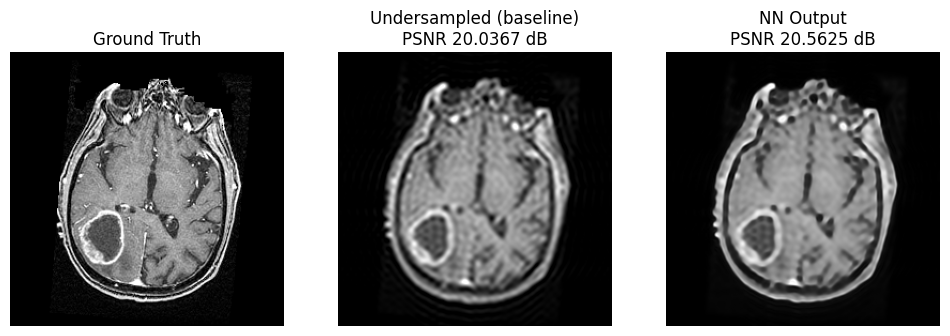

In [ ]:
plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.imshow(gt_img, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(us_img, cmap="gray")
plt.title(f"Undersampled (baseline)\nPSNR {baseline_psnr:.4f} dB")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(nn_img, cmap="gray")
plt.title(f"NN Output\nPSNR {nn_psnr:.4f} dB")
plt.axis("off")

plt.show()